In [5]:
import numpy as np
import os
import time
import math
import math
import random


In [104]:
def create_volume(outliers):
    true_mean = np.zeros((64, 64))
    true_std = np.zeros((64, 64))
    volume = np.zeros((5000, 64, 64))
    np.random.seed(1)
    for i in range(64):
        for j in range(64):
            s = np.random.normal(1, 1, 5000)
            #volume[i][j][k] = s
            for k in range(5000):
                
                volume[k][i][j] = s[k]
        # for o in range(500):
            true_mean[i][j] = np.mean(s)
            true_std[i][j] = np.std(s)
            
            #Add Outliers
            indicies = np.random.randint(0, 4999, outliers)
            for o in range(outliers):
                g = indicies[o]
                outs = np.random.uniform(4, 11)
                volume[g][i][j] = outs
                
    return volume, true_mean, true_std

In [2]:
np.shape(volume)

(5000, 64, 64)

In [105]:
def algorithm(data, t):
    
    # Initialize variables for running stats
    n = 0      # Count of valid values
    mean = 0   # Running mean
    M2 = 0     # Sum of squares of differences from the current mean
    threshold = t  # Number of standard deviations to trim outliers

    # Loop through each value in the stream
    for value in data:
        # Outlier detection: only skip trimming for the first value
        if n > 5:
            # Calculate temporary standard deviation
            variance = M2 / (n - 1) if n > 1 else 0
            stddev = math.sqrt(variance)

            # Check if value is within threshold * stddev from the mean
            if abs(value - mean) > threshold * stddev:
                #print(f"Value {value} is considered an outlier and will be skipped.")
                continue

        # Update running statistics for non-outliers
        n += 1
        delta = value - mean
        mean += delta / n
        delta2 = value - mean
        M2 += delta * delta2

        # Compute the standard deviation for the current set
        if n < 2:
            stddev = float('nan')  # Stddev undefined for the first value
        else:
            variance = M2 / (n - 1)
            stddev = math.sqrt(variance)

        # Output the running mean and standard deviation after each valid value
        #print(f"After {n} valid values: Mean = {mean}, Stddev = {stddev}")
    return mean, stddev

In [106]:
def image_algorithm(volume, t, b):
    count_image = np.zeros((64, 64))
    mean_image = np.zeros((64, 64))
    sum_squared_image = np.zeros((64, 64))
    threshold = t
    buffer_size = b
    for i in range(5000):
        for j in range(64):
            for k in range(64):
                n = count_image[j][k]      # Count of valid values
                mean = mean_image[j][k]   # Running mean
                M2 = sum_squared_image[j][k]
                value = volume[i][j][k]
                
                if n > buffer_size:     
                    # Calculate temporary standard deviation
                    variance = M2  / (n - 1) if n > 1 else 0
                    stddev = math.sqrt(variance)

                    # Check if value is within threshold * stddev from the mean
                    if abs(value - mean) > threshold * stddev:
                        #print(f"Value {value} is considered an outlier and will be skipped.")
                        continue

                # Update running statistics for non-outliers
                n += 1
                delta = value - mean
                mean += delta / n
                delta2 = value - mean
                M2 += delta * delta2

                    
                    #Update Values
                count_image[j][k] = n     # Count of valid values
                mean_image[j][k] = mean  # Running mean
                sum_squared_image[j][k] = M2
            
    std_image =  np.sqrt(sum_squared_image  / (count_image - 1))
    return mean_image, std_image


        


In [110]:
final = dict()
for buffer_size in range(5, 21, 5):
    percent_mean_errors = []
    percent_std_errors = []
    volume, true_mean, true_std = create_volume(500)
    mean, std = image_algorithm(volume, 3, buffer_size)
    diff_in_means = mean - true_mean
    diff_in_std = std - true_std
    percent_mean_errors.append(abs(diff_in_means/true_mean) * 100)
    percent_std_errors.append(abs(diff_in_std/ true_std) * 100)
    vals = 0
    outliers_mean = 0
    outliers_std = 0
    re_mean = np.reshape(percent_mean_errors, (4096, 1))
    re_std = np.reshape(percent_std_errors, (4096, 1))

    for i in range(len(re_mean)):
        if(re_mean[i] > 10):
            outliers_mean +=1
        if(re_std[i] > 10):
            outliers_std +=1
            

    final[buffer_size] = (np.mean(percent_mean_errors), np.mean(percent_std_errors), outliers_mean, outliers_std)

    
    


In [111]:
final

{5: (1.3866727784286645, 2.722571061654836, 44, 210),
 10: (1.8528256938360343, 3.33186680779467, 66, 305),
 15: (2.245058530308408, 3.902431923688292, 81, 387),
 20: (2.5742370822464493, 4.4331060458479845, 91, 467)}

In [84]:
np.mean(percent_mean_errors) 

2.5742370822464493

In [85]:
np.mean(percent_std_errors)

4.4331060458479845

In [36]:
percent_std_errors

[array([[1.88269686, 2.98642543, 0.95986561, ..., 2.47829182, 1.91752363,
         6.19798848],
        [1.40488838, 2.20987878, 6.36858271, ..., 1.43567008, 0.97825684,
         3.75883117],
        [1.91214175, 0.56725393, 2.82206572, ..., 0.64514659, 6.27606078,
         0.8409876 ],
        ...,
        [0.73379688, 4.69189199, 1.77846888, ..., 0.63323294, 0.54205911,
         0.2572461 ],
        [2.1157111 , 3.06296815, 0.67639817, ..., 0.70618926, 2.1762901 ,
         1.03513707],
        [3.02724653, 1.11616571, 1.96072797, ..., 2.12243927, 1.56287781,
         4.56283576]])]

In [99]:
check = np.reshape(percent_std_errors, (4096, 1))

In [100]:
vals = 0
for i in range(len(check)):
    if(check[i] > 15):
        print(i)
        print(check[i])
        vals +=1
        
        
        
        
vals

13
[19.94604514]
41
[15.11762305]
44
[29.2724714]
53
[16.53830513]
63
[18.46312654]
89
[20.07549627]
124
[26.4018755]
127
[15.51751548]
138
[26.24384841]
155
[16.20439385]
205
[20.90654185]
219
[15.2029044]
260
[21.73344637]
295
[16.4220044]
307
[21.31933621]
312
[16.57285632]
409
[15.96568533]
443
[18.60957631]
444
[31.07578571]
445
[17.86136694]
457
[39.14391514]
458
[17.77286922]
469
[23.17307908]
516
[15.71182348]
573
[23.0714483]
594
[15.29007862]
595
[19.53675701]
610
[19.65768638]
629
[19.82879819]
630
[32.29511319]
672
[20.71500833]
735
[16.7583139]
750
[15.92863383]
755
[18.41662201]
778
[16.91667028]
781
[17.5193889]
848
[15.99935298]
854
[20.25078626]
871
[16.48411946]
883
[27.50320176]
889
[20.44482417]
924
[15.14717258]
981
[17.64200286]
1005
[16.44360233]
1011
[41.58799451]
1068
[17.16011275]
1080
[18.9526938]
1081
[27.81719625]
1099
[18.45828329]
1107
[16.48449639]
1123
[19.02903759]
1128
[16.03524021]
1143
[18.22061156]
1172
[15.07198251]
1201
[24.67210359]
1225
[18.431

200

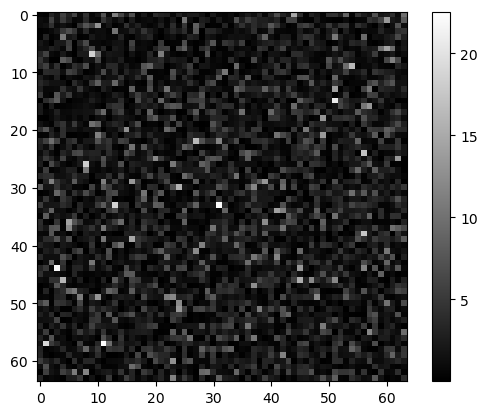

In [94]:
import matplotlib.pyplot as plt
plt.imshow(percent_mean_errors[0], cmap='gray')
plt.colorbar()

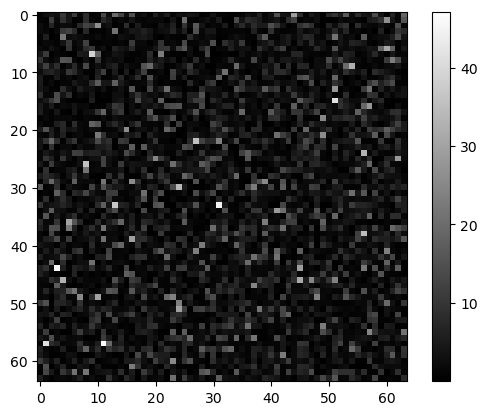

In [98]:
import matplotlib.pyplot as plt
plt.imshow(percent_std_errors[0], cmap='gray')
plt.colorbar()

In [70]:
np.shape(volume[41][:][:])

(64, 64)

In [71]:
np.mean(volume[41][:][:])

1.5960532070221185

In [72]:
volume[41][:][:]

array([[ 0.11237104, -0.298407  ,  1.45732837, ...,  0.26496274,
        -0.0256231 ,  0.79447977],
       [ 1.13055695, -0.57089902, -0.9263509 , ...,  1.00333327,
         2.35744452,  1.4142649 ],
       [ 3.59674724,  1.58017815, -0.65964432, ...,  2.36658051,
         0.61803937,  2.18744757],
       ...,
       [ 0.86081085,  0.39115673,  7.54769617, ...,  9.45975518,
         1.43499391,  1.33271374],
       [ 0.39248511,  0.17638611,  0.79519303, ...,  1.07300954,
         0.75869663,  0.48349973],
       [ 0.31364675,  1.64962354,  2.20578934, ...,  2.28666756,
         2.14725023,  6.63069484]])

In [79]:
check  = np.reshape(volume[63][:][:], 4096)

In [80]:
check[:20]

array([ 0.70190716,  0.53443193,  1.00125392,  4.04635186,  0.46622631,
        1.52212211,  2.67937168,  0.54012865,  0.82066124,  2.18752867,
        9.43230557,  1.59034126,  0.41680955,  1.67456113, -0.38247585,
        5.5903341 ,  1.41811928,  1.50532969,  0.2245419 ,  3.19965864])